L = 2, N = 2, dim = 3
init = (1, 1), target = (0, 2)
sideband = +1 -> f_drive_hz_init = 1055.21 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 1055.21 Hz -> T_Rabi = 1.8736 ms (+/- 0.0000), f_Rabi = 533.73 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 1092.207 Hz (+/- 0.694), OmegaR = 1136.228 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 1092.21 Hz -> T_Rabi = 1.8204 ms (+/- 0.0000), f_Rabi = 549.33 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 1116.773 Hz (+/- 0.568), OmegaR = 1192.229 Hz

=== SUMMARY ===
f_drive_hz_init       = 1055.211 Hz
f_center_rabi_init    = 1092.207 Hz
f_center_rabi_final   = 1116.773 Hz
T_rabi_init           = 1.8736 ms
T_rabi_final         

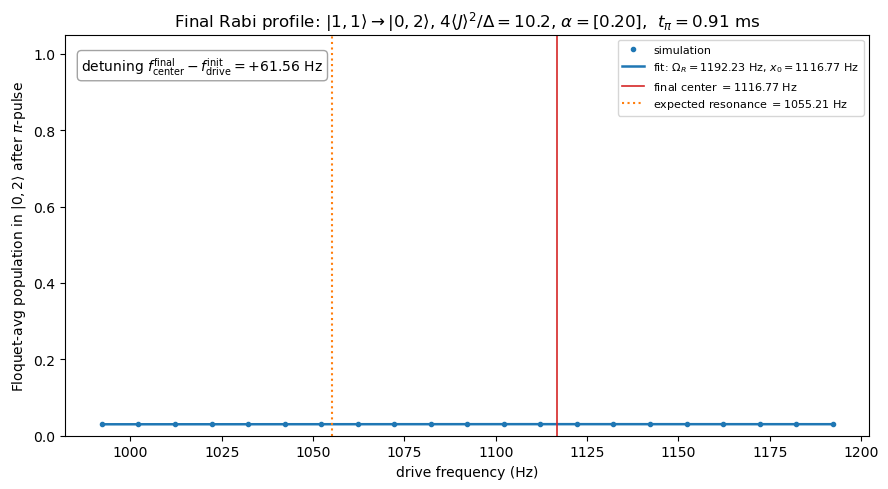

saved figure -> C:\Users\eunic\resonance_Escan.png


In [12]:
# =============================================================
# resonance_Escan.py
#
# Iterative resonance finder for photon-assisted tunneling between a chosen
# initial Fock state and target Fock state under multi-tone lattice-depth
# modulation. Workflow:
#   1. preliminary time scan at f_drive_hz_init -> fit T_rabi_init
#   2. frequency scan (pi-pulse profile) -> fit center f_center_rabi_init
#   3. move drive to f_center_rabi_init, redo time scan -> fit T_rabi_final
#   4. redo frequency profile with the new pi-pulse time -> fit f_center_rabi_final
#   5. plot the final fit and report the detuning f_center_rabi_final - f_drive_hz_init
#
# Both J AND U now oscillate with the modulated lattice depth V(t); the
# interaction term is therefore time-dependent and is propagated inside the RHS
# alongside the tunneling. A static per-site chemical potential (mu_offset_hz)
# can be added to each site.
# =============================================================

import itertools
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit

twopi = 2.0 * np.pi

# =============================================================
# DEPTH -> (J, U) CONVERTERS  (module-level: no closure dependence)
# =============================================================
J_OUTPUT_UNITS = "Hz"
E_R_HZ = 1.0

# Found by fitting lattice depth to J for the Wannier functions (agrees w/ data).
def V_to_J(V):
    V = np.asarray(V, dtype=float)
    a = 284.4; b = -0.2922; c = 30.69; d = -0.1304   # Er in, Hz out
    return a * np.exp(b * V) + c * np.exp(d * V)

def J_angular(V):
    Jval = V_to_J(V)
    if J_OUTPUT_UNITS == "Hz":        return twopi * Jval
    elif J_OUTPUT_UNITS == "angular": return Jval
    elif J_OUTPUT_UNITS == "Er":      return twopi * E_R_HZ * Jval
    else: raise ValueError("J_OUTPUT_UNITS must be 'Hz', 'angular', or 'Er'")

# On-site interaction vs lattice depth (Er in, Hz out).
def U_of_V(V):
    V = np.asarray(V, dtype=float)
    a = 193.9; b = -60.06
    return a * V**0.25 + b

def U_angular(V):
    return twopi * U_of_V(V)


# =============================================================
# MAIN FUNCTION
# =============================================================
def resonance_Escan(state_init,
                    state_target,
                    V0_ER,
                    Delta_hz,
                    sideband,
                    alpha,
                    mu_offset_hz,
                    # scan / fit controls (kept as keyword args w/ original defaults)
                    N_PERIODS_PER_RABI=100,
                    TIME_SAMPLES_PER_PERIOD=20,
                    PULSE_SPAN_HZ=100.0,
                    PULSE_N_POINTS=21,
                    PULSE_SAMPLES_PER_PERIOD=40,
                    txt_path="simulation_results_Escan.txt",
                    fig_path="resonance_Escan.png",
                    show=False):
    """
    Iterative resonance finder. Returns a dict of results.

    Parameters
    ----------
    state_init   : list[int]   initial Fock state (length L)
    V0_ER        : float        static lattice depth (Er)
    Delta_hz     : float        tilt per site (Hz)
    sideband     : int (+1/-1)  +1 -> guess = Delta + U_mean_0, target (0,2,...);
                                -1 -> guess = Delta - U_mean_0, target (...,2,0...)
    alpha        : list[float]  depth modulation amplitude(s); must match #tones (=1)
    mu_offset_hz : list[float]  per-site energy offset (Hz), length L, or empty []
    """

    # ----------------------------------------------------------------
    # Static lattice depth + drive amplitudes
    # ----------------------------------------------------------------
    V0    = float(V0_ER)
    alpha = np.atleast_1d(np.asarray(alpha, dtype=float))
    Delta = twopi * Delta_hz

    sideband = int(np.sign(sideband))

    state_init = list(state_init)
    L = len(state_init)
    N = sum(state_init)

    # ----------------------------------------------------------------
    # Mean / static interaction values from the depth converter
    # ----------------------------------------------------------------
    omega_init_for_mean = twopi * np.array([Delta_hz])  # placeholder; replaced below
    # Floquet-period average of U over the modulated depth (single drive tone).
    # We compute U_mean_0 at the nominal drive period, which is set once the
    # frequency guess is known; for the *guess* we need U_mean_0, so average over
    # one period of any representative tone -> use V(t) period independence: the
    # time-average of cos over a full period is 0 regardless of frequency, so any
    # nonzero omega gives the same average. Use 1 Hz as a safe representative.
    def _depth_trace(om, n_sub=10000):
        T = 1.0 / (om.min() / twopi)
        t = np.linspace(0.0, T, n_sub, endpoint=False)
        return V0 * (1.0 + np.sum(alpha[:, None] * np.cos(np.outer(om, t)), axis=0))

    om_rep = twopi * np.array([1.0])
    Vt_rep = _depth_trace(om_rep)
    U_mean_0 = U_of_V(Vt_rep).mean()
    U_V0     = float(U_of_V(V0))

    # ----------------------------------------------------------------
    # Drive frequency guess + target state from the sideband sign
    # ----------------------------------------------------------------
    f_drive_hz_init = Delta_hz + sideband * U_mean_0
    if sum(state_target) != N:
        raise ValueError("init and target must share particle number N. "
                         "(target=%s, N=%d)" % (state_target, N))

    # ----------------------------------------------------------------
    # Per-site chemical potential (angular). Empty -> zeros.
    # ----------------------------------------------------------------
    mu_in = np.asarray(mu_offset_hz, dtype=float).ravel()
    if mu_in.size == 0:
        mu_site_hz = np.zeros(L)
    elif mu_in.size == L:
        mu_site_hz = mu_in.copy()
    else:
        raise ValueError("mu_offset_hz must be empty or length L=%d (got %d)."
                         % (L, mu_in.size))
    mu_site = twopi * mu_site_hz  # angular

    # ----------------------------------------------------------------
    # Fixed-N basis
    # ----------------------------------------------------------------
    def generate_basis(L, N):
        return [tuple(occ) for occ in itertools.product(range(N + 1), repeat=L)
                if sum(occ) == N]

    basis = generate_basis(L, N)
    index = {s: i for i, s in enumerate(basis)}
    dim   = len(basis)

    if tuple(state_init) not in index or tuple(state_target) not in index:
        raise ValueError("init/target state not present in the N=%d basis." % N)

    print("L = %d, N = %d, dim = %d" % (L, N, dim))
    print("init = %s, target = %s" % (tuple(state_init), tuple(state_target)))
    print("sideband = %+d -> f_drive_hz_init = %.2f Hz" % (sideband, f_drive_hz_init))
    print("static depth V0 = %.4g Er -> J(V0) = %.4f Hz" % (V0, J_angular(V0)/twopi))
    print("U_mean_0 = %.4f Hz, U(V0) = %.4f Hz" % (U_mean_0, U_V0))

    # ----------------------------------------------------------------
    # Hamiltonian pieces.
    #   H_static : tilt + per-site chemical potential  (time-independent)
    #   H_int_unit : sum_i 0.5 n_i(n_i-1)  -> scaled by U_angular(V(t)) at runtime
    #   H_hop_unit : unit hopping           -> scaled by J_angular(V(t)) at runtime
    # ----------------------------------------------------------------
    def build_static_diag():
        H = np.zeros((dim, dim), dtype=complex)
        site = np.arange(L)
        for a, state in enumerate(basis):
            n = np.array(state)
            tilt = -Delta * np.sum(site * n)
            chem = np.sum(mu_site * n)
            H[a, a] = tilt + chem
        return H

    def build_int_unit():
        # Diagonal: sum_i 0.5 * n_i (n_i - 1). Multiplied by U(t) in the RHS.
        H = np.zeros((dim, dim), dtype=complex)
        for a, state in enumerate(basis):
            n = np.array(state)
            H[a, a] = 0.5 * np.sum(n * (n - 1))
        return H

    def build_hop_unit():
        H = np.zeros((dim, dim), dtype=complex)
        for a, state in enumerate(basis):
            n = np.array(state)
            for j in range(L - 1):
                if n[j] > 0:
                    new = n.copy(); amp = np.sqrt(n[j]) * np.sqrt(n[j+1] + 1)
                    new[j] -= 1; new[j+1] += 1
                    H[index[tuple(new)], a] += -amp
                if n[j+1] > 0:
                    new = n.copy(); amp = np.sqrt(n[j+1]) * np.sqrt(n[j] + 1)
                    new[j+1] -= 1; new[j] += 1
                    H[index[tuple(new)], a] += -amp
        return H

    H_static   = build_static_diag()
    H_int_unit = build_int_unit()
    H_hop_unit = build_hop_unit()

    # ----------------------------------------------------------------
    # State and projector
    # ----------------------------------------------------------------
    psi0 = np.zeros(dim, dtype=complex)
    psi0[index[tuple(state_init)]] = 1.0
    P_target = np.zeros((dim, dim), dtype=complex)
    P_target[index[tuple(state_target)], index[tuple(state_target)]] = 1.0

    # ----------------------------------------------------------------
    # Evolution helpers
    # ----------------------------------------------------------------
    def V_of_t(t, om):
        return V0 * (1.0 + np.sum(alpha * np.cos(om * t)))

    def evolve(n_periods, samples_per_period, om, t_end=None):
        T_ref_local = 1.0 / (om.min() / twopi)
        if t_end is None:
            t_end = n_periods * T_ref_local
            ntimes = n_periods * samples_per_period + 1
        else:
            n_per = max(1, int(round(t_end / T_ref_local)))
            ntimes = n_per * samples_per_period + 1
        def rhs(t, psi):
            Vt = V_of_t(t, om)
            Jt = J_angular(Vt)
            Ut = U_angular(Vt)
            H = H_static + Ut * H_int_unit + Jt * H_hop_unit
            return -1j * H.dot(psi)
        times = np.linspace(0.0, t_end, ntimes)
        sol = solve_ivp(rhs, (0.0, t_end), psi0, t_eval=times,
                        rtol=1e-9, atol=1e-9, method="RK45")
        return times, sol.y.T

    def rabi_model(t, A, T_rabi, offset):
        return offset + 0.5 * A * (1.0 - np.cos(2.0 * np.pi * t / T_rabi))

    def ket(s):
        return r"|%s\rangle" % ",".join(str(x) for x in s)

    def fit_time_trace(f_drive_hz, label=""):
        om = twopi * np.array([f_drive_hz])
        n_periods = 3 * N_PERIODS_PER_RABI
        times, psis = evolve(n_periods, TIME_SAMPLES_PER_PERIOD, om=om)
        ptar = np.array([np.vdot(p, P_target.dot(p)).real for p in psis])

        w = TIME_SAMPLES_PER_PERIOD
        kernel = np.ones(w) / w
        ptar_avg = np.convolve(ptar, kernel, mode="valid")
        t_avg    = times[(w-1)//2 : (w-1)//2 + len(ptar_avg)]

        sig = ptar_avg - ptar_avg.mean()
        dt  = t_avg[1] - t_avg[0]
        freqs_fft = np.fft.rfftfreq(len(sig), d=dt)
        power = np.abs(np.fft.rfft(sig)); power[0] = 0.0
        f_dom = freqs_fft[np.argmax(power)]
        T_guess = 1.0 / f_dom if f_dom > 0 else (t_avg[-1] - t_avg[0])
        p0 = [ptar_avg.max() - ptar_avg.min(), T_guess, ptar_avg.min()]
        try:
            popt, pcov = curve_fit(rabi_model, t_avg, ptar_avg, p0=p0, maxfev=20000)
            T_fit = popt[1]
            T_err = np.sqrt(np.diag(pcov))[1]
            fit_ok = True
            print("[time %s] f_drive = %.2f Hz -> T_Rabi = %.4f ms (+/- %.4f), "
                  "f_Rabi = %.2f Hz" % (label, f_drive_hz, 1000*T_fit, 1000*T_err, 1.0/T_fit))
        except RuntimeError:
            popt = p0; T_fit = T_guess; fit_ok = False
            print("[time %s] fit did not converge; using FFT guess T = %.4f ms"
                  % (label, 1000*T_fit))
        return T_fit, popt, t_avg, ptar_avg, fit_ok

    def pulse_lineshape(x, A, OmegaR, x0):
        gen = np.sqrt(OmegaR**2 + (x - x0)**2)
        lor = OmegaR**2 / (OmegaR**2 + (x - x0)**2)
        return A * lor * np.sin(np.pi * gen / (2.0 * OmegaR))**2

    def pulsed_population(f_drive, t_pi):
        om = twopi * np.array([f_drive])
        tt, pp = evolve(None, PULSE_SAMPLES_PER_PERIOD, om=om, t_end=t_pi)
        pj = np.array([np.vdot(p, P_target.dot(p)).real for p in pp])
        T_drive = 1.0 / f_drive
        n_final = max(1, int(round((tt[-1] - tt[0]) / T_drive)))
        wloc = max(1, len(tt) // max(1, n_final))
        if wloc < len(pj):
            kloc = np.ones(wloc) / wloc
            return np.convolve(pj, kloc, mode="valid")[-1]
        return pj.mean()

    def fit_profile(f_center_guess, t_pi, T_fit, label=""):
        scan_freqs = np.linspace(f_center_guess - PULSE_SPAN_HZ,
                                 f_center_guess + PULSE_SPAN_HZ, PULSE_N_POINTS)
        pulse_pop = np.array([pulsed_population(f, t_pi) for f in scan_freqs])
        f_peak = scan_freqs[np.argmax(pulse_pop)]

        OmegaR_guess = 1.0 / T_fit
        p0_line = [pulse_pop.max(), OmegaR_guess, f_peak]
        try:
            popt_line, pcov_line = curve_fit(pulse_lineshape, scan_freqs, pulse_pop,
                                             p0=p0_line, maxfev=40000)
            popt_line[1] = abs(popt_line[1])
            x0 = popt_line[2]
            perr = np.sqrt(np.diag(pcov_line))
            fit_ok = True
            print("[profile %s] center x0 = %.3f Hz (+/- %.3f), OmegaR = %.3f Hz"
                  % (label, x0, perr[2], popt_line[1]))
        except RuntimeError:
            popt_line = p0_line; x0 = f_peak; fit_ok = False
            print("[profile %s] lineshape fit did not converge; using peak = %.3f Hz"
                  % (label, f_peak))
        return scan_freqs, pulse_pop, popt_line, x0, fit_ok

    def J_mean_0(om, n_sub=10000):
        T = 1.0 / (om.min() / twopi)
        t = np.linspace(0.0, T, n_sub, endpoint=False)
        Vt = V0 * (1.0 + np.sum(alpha[:, None] * np.cos(np.outer(om, t)), axis=0))
        return V_to_J(Vt).mean()

    omega_init = twopi * np.array([f_drive_hz_init])
    print("J_mean_0      = %.4f Hz" % J_mean_0(omega_init))
    print("J(V0)         = %.4f Hz" % V_to_J(V0))

    # ----------------------------------------------------------------
    # STEP 2: preliminary time scan
    # ----------------------------------------------------------------
    print("\n=== STEP 2: preliminary time scan at f_drive_hz_init ===")
    T_rabi_init, popt_t_init, t_avg_i, ptar_avg_i, ok_t_init = \
        fit_time_trace(f_drive_hz_init, label="init")

    # ----------------------------------------------------------------
    # STEP 3: frequency profile scan
    # ----------------------------------------------------------------
    print("\n=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===")
    t_pi_init = 0.5 * T_rabi_init
    sf_i, pp_i, popt_l_init, f_center_rabi_init, ok_l_init = \
        fit_profile(f_drive_hz_init, t_pi_init, T_rabi_init, label="init")

    # ----------------------------------------------------------------
    # STEP 4: resonant time scan
    # ----------------------------------------------------------------
    print("\n=== STEP 4: resonant time scan at f_center_rabi_init ===")
    T_rabi_final, popt_t_fin, t_avg_f, ptar_avg_f, ok_t_fin = \
        fit_time_trace(f_center_rabi_init, label="final")

    # ----------------------------------------------------------------
    # STEP 5: profile scan with new pi-pulse
    # ----------------------------------------------------------------
    print("\n=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===")
    t_pi_final = 0.5 * T_rabi_final
    sf_f, pp_f, popt_l_fin, f_center_rabi_final, ok_l_fin = \
        fit_profile(f_center_rabi_init, t_pi_final, T_rabi_final, label="final")

    detuning = f_center_rabi_final - f_drive_hz_init
    print("\n=== SUMMARY ===")
    print("f_drive_hz_init       = %.3f Hz" % f_drive_hz_init)
    print("f_center_rabi_init    = %.3f Hz" % f_center_rabi_init)
    print("f_center_rabi_final   = %.3f Hz" % f_center_rabi_final)
    print("T_rabi_init           = %.4f ms" % (1000*T_rabi_init))
    print("T_rabi_final          = %.4f ms" % (1000*T_rabi_final))
    print("detuning (final-init) = %+.3f Hz" % detuning)

    # ----------------------------------------------------------------
    # APPEND RESULTS TO RUNNING TXT DATABASE
    # ----------------------------------------------------------------
    FIELDS = ["V0_ER", "alpha", "N", "L", "sideband",
              "J_mean_0", "J(V0)", "U_mean_0", "U(V0)",
              "Delta_hz",
              "f_resonance_hz", "rabi_freq_final_hz", "detuning",
              "initial_state", "final_state", "mu_offset_hz"]

    row = {
        "V0_ER":              V0,
        "alpha":              ";".join("%.6g" % a for a in alpha),
        "N":                  N,
        "L":                  L,
        "sideband":           sideband,
        "J_mean_0":           J_mean_0(omega_init),
        "J(V0)":              float(V_to_J(V0)),
        "U_mean_0":           U_mean_0,
        "U(V0)":              U_V0,
        "Delta_hz":           Delta_hz,
        "f_resonance_hz":     f_center_rabi_final,
        "rabi_freq_final_hz": 1.0 / T_rabi_final,
        "detuning":           detuning,
        "initial_state":      "".join(str(x) for x in state_init),
        "final_state":        "".join(str(x) for x in state_target),
        "mu_offset_hz":       ";".join("%.6g" % m for m in mu_site_hz),
    }

    write_header = (not os.path.exists(txt_path)) or os.path.getsize(txt_path) == 0
    with open(txt_path, "a", newline="") as f:
        if write_header:
            f.write("\t".join(FIELDS) + "\n")
        f.write("\t".join(str(row[k]) for k in FIELDS) + "\n")
    print("appended results -> %s" % os.path.abspath(txt_path))

    # ----------------------------------------------------------------
    # PLOT: final fitted Rabi profile
    # ----------------------------------------------------------------
    amp_str = ", ".join("%.2f" % a for a in alpha)
    Jsq_over_Delta = 4.0 * (J_mean_0(omega_init))**2 / (Delta_hz)
    plt.figure(figsize=(9, 5))
    plt.plot(sf_f, pp_f, "o", color="C0", ms=3, label="simulation")
    if ok_l_fin:
        xfine = np.linspace(sf_f[0], sf_f[-1], 1000)
        plt.plot(xfine, pulse_lineshape(xfine, *popt_l_fin), "-", color="C0", lw=1.8,
                 label=r"fit: $\Omega_R=%.2f$ Hz, $x_0=%.2f$ Hz"
                       % (popt_l_fin[1], f_center_rabi_final))
    plt.axvline(f_center_rabi_final, color="C3", ls="-", lw=1.2,
                label=r"final center $=%.2f$ Hz" % f_center_rabi_final)
    plt.axvline(f_drive_hz_init, color="C1", ls=":", lw=1.5,
                label=r"expected resonance $=%.2f$ Hz" % f_drive_hz_init)
    plt.xlabel("drive frequency (Hz)")
    plt.ylabel(r"Floquet-avg population in $%s$ after $\pi$-pulse" % ket(state_target))
    plt.ylim(0, 1.05)
    plt.title(r"Final Rabi profile: $%s \to %s$, $4\langle J\rangle^2/\Delta=%.1f$, "
              r"$\alpha=[%s]$,  $t_\pi=%.2f$ ms"
              % (ket(state_init), ket(state_target), Jsq_over_Delta, amp_str, 1000*t_pi_final))
    plt.annotate(r"detuning $f_\mathrm{center}^\mathrm{final}-f_\mathrm{drive}^\mathrm{init}"
                 r"=%+.2f$ Hz" % detuning,
                 xy=(0.02, 0.95), xycoords="axes fraction", va="top", ha="left",
                 fontsize=10, bbox=dict(boxstyle="round", fc="w", ec="0.6", alpha=0.9))
    plt.legend(fontsize=8, loc="upper right")
    plt.tight_layout()
    plt.savefig(fig_path, dpi=120)
    if show:
        plt.show()
    plt.close()
    print("saved figure -> %s" % os.path.abspath(fig_path))

    return {
        "f_drive_hz_init": f_drive_hz_init,
        "f_center_rabi_init": f_center_rabi_init,
        "f_center_rabi_final": f_center_rabi_final,
        "T_rabi_init": T_rabi_init,
        "T_rabi_final": T_rabi_final,
        "detuning": detuning,
        "U_mean_0": U_mean_0,
        "U(V0)": U_V0,
        "N": N, "L": L, "sideband": sideband,
        "state_target": state_target,
        "mu_offset_hz": mu_site_hz.tolist(),
        "scan_freqs": sf_f, "pulse_pop": pp_f,
        "popt_lineshape": popt_l_fin, "lineshape_ok": ok_l_fin,
    }


# =============================================================
# Example call (mirrors original script's defaults)
# =============================================================
if __name__ == "__main__":
    res = resonance_Escan(
        state_init   = [1, 1],
        state_target = [0, 2],
        V0_ER        = 7.5,
        Delta_hz     = 795.0,
        sideband     = +1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 2, N = 2, dim = 3
init = (1, 1), target = (2, 0)
sideband = +1 -> f_drive_hz_init = 1080.21 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 1080.21 Hz -> T_Rabi = 41.2956 ms (+/- 0.0001), f_Rabi = 24.22 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 1081.893 Hz (+/- 0.210), OmegaR = 24.878 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 1081.89 Hz -> T_Rabi = 41.2673 ms (+/- 0.0001), f_Rabi = 24.23 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 1081.896 Hz (+/- 0.211), OmegaR = 24.895 Hz

=== SUMMARY ===
f_drive_hz_init       = 1080.211 Hz
f_center_rabi_init    = 1081.893 Hz
f_center_rabi_final   = 1081.896 Hz
T_rabi_init           = 41.2956 ms
T_rabi_final          = 

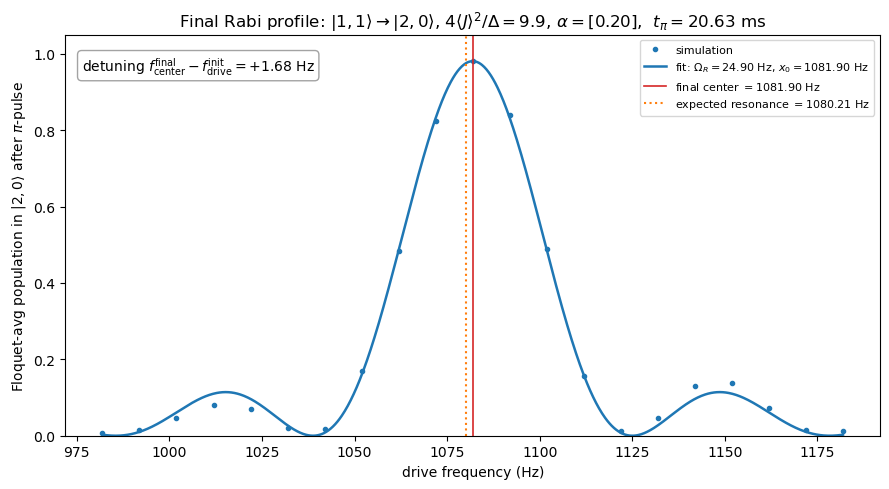

saved figure -> C:\Users\eunic\resonance_Escan.png


In [7]:
# E + U resonance, no walls, 2 sites
res = resonance_Escan(
        state_init   = [1, 1],
        state_target = [2, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = +1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 2, N = 2, dim = 3
init = (1, 1), target = (0, 2)
sideband = -1 -> f_drive_hz_init = 559.79 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 559.79 Hz -> T_Rabi = 42.2448 ms (+/- 0.0001), f_Rabi = 23.67 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 572.817 Hz (+/- 0.451), OmegaR = 25.444 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 572.82 Hz -> T_Rabi = 46.7326 ms (+/- 0.0001), f_Rabi = 21.40 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 572.263 Hz (+/- 0.421), OmegaR = 22.233 Hz

=== SUMMARY ===
f_drive_hz_init       = 559.789 Hz
f_center_rabi_init    = 572.817 Hz
f_center_rabi_final   = 572.263 Hz
T_rabi_init           = 42.2448 ms
T_rabi_final          = 46.7326 

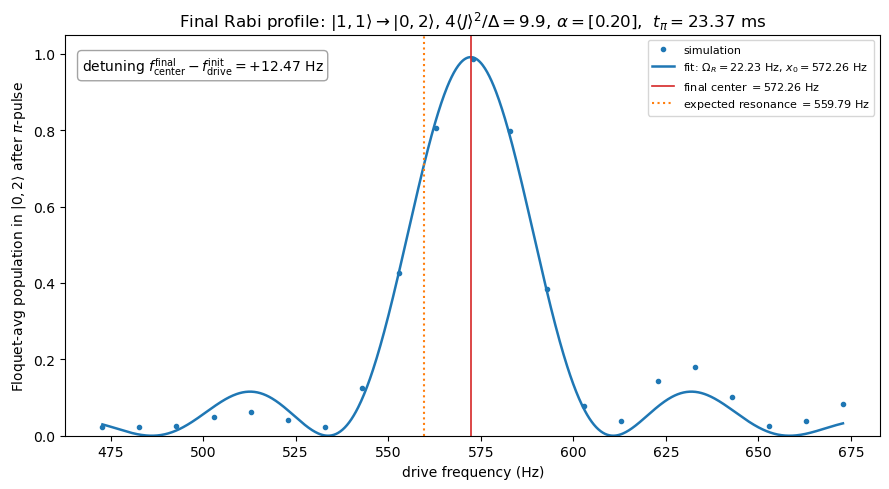

saved figure -> C:\Users\eunic\resonance_Escan.png


In [13]:
# E - U resonance, no walls, 2 sites
res = resonance_Escan(
        state_init   = [1, 1],
        state_target = [0, 2],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = -1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 2, N = 1, dim = 2
init = (1, 0), target = (0, 1)
sideband = +0 -> f_drive_hz_init = 820.00 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 820.00 Hz -> T_Rabi = 58.1938 ms (+/- 0.0001), f_Rabi = 17.18 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 825.749 Hz (+/- 0.164), OmegaR = 17.768 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 825.75 Hz -> T_Rabi = 60.7638 ms (+/- 0.0001), f_Rabi = 16.46 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 825.672 Hz (+/- 0.161), OmegaR = 16.875 Hz

=== SUMMARY ===
f_drive_hz_init       = 820.000 Hz
f_center_rabi_init    = 825.749 Hz
f_center_rabi_final   = 825.672 Hz
T_rabi_init           = 58.1938 ms
T_rabi_final          = 60.7638 

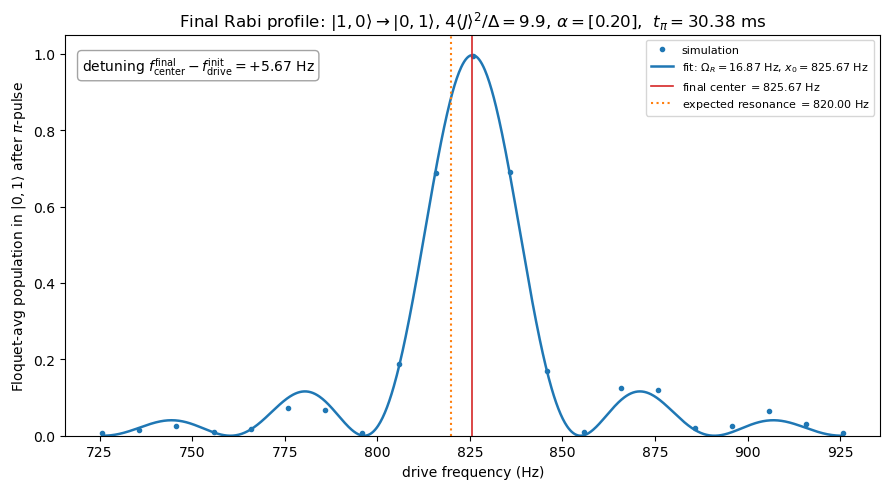

saved figure -> C:\Users\eunic\resonance_Escan.png


In [14]:
# E single-particle resonance, no walls, 2 sites
res = resonance_Escan(
        state_init   = [1, 0],
        state_target = [0, 1],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = 0,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 3, N = 2, dim = 6
init = (1, 1, 0), target = (2, 0, 0)
sideband = +1 -> f_drive_hz_init = 1080.21 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 1080.21 Hz -> T_Rabi = 41.1664 ms (+/- 0.0001), f_Rabi = 24.29 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 1079.688 Hz (+/- 0.217), OmegaR = 24.952 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 1079.69 Hz -> T_Rabi = 41.2165 ms (+/- 0.0001), f_Rabi = 24.26 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 1079.683 Hz (+/- 0.216), OmegaR = 24.913 Hz

=== SUMMARY ===
f_drive_hz_init       = 1080.211 Hz
f_center_rabi_init    = 1079.688 Hz
f_center_rabi_final   = 1079.683 Hz
T_rabi_init           = 41.1664 ms
T_rabi_final      

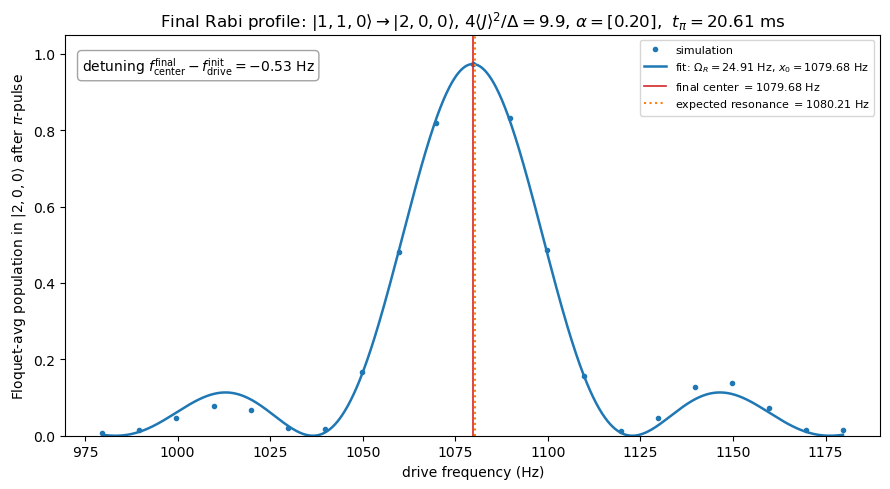

saved figure -> C:\Users\eunic\resonance_Escan.png


In [15]:
# E+U, no walls, 3 sites
res = resonance_Escan(
        state_init   = [1, 1, 0],
        state_target = [2, 0, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = +1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 3, N = 2, dim = 6
init = (1, 1, 0), target = (0, 2, 0)
sideband = -1 -> f_drive_hz_init = 559.79 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 559.79 Hz -> T_Rabi = 43.2413 ms (+/- 0.0001), f_Rabi = 23.13 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 571.452 Hz (+/- 0.405), OmegaR = 24.604 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 571.45 Hz -> T_Rabi = 46.7247 ms (+/- 0.0001), f_Rabi = 21.40 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 571.003 Hz (+/- 0.430), OmegaR = 22.230 Hz

=== SUMMARY ===
f_drive_hz_init       = 559.789 Hz
f_center_rabi_init    = 571.452 Hz
f_center_rabi_final   = 571.003 Hz
T_rabi_init           = 43.2413 ms
T_rabi_final          = 46

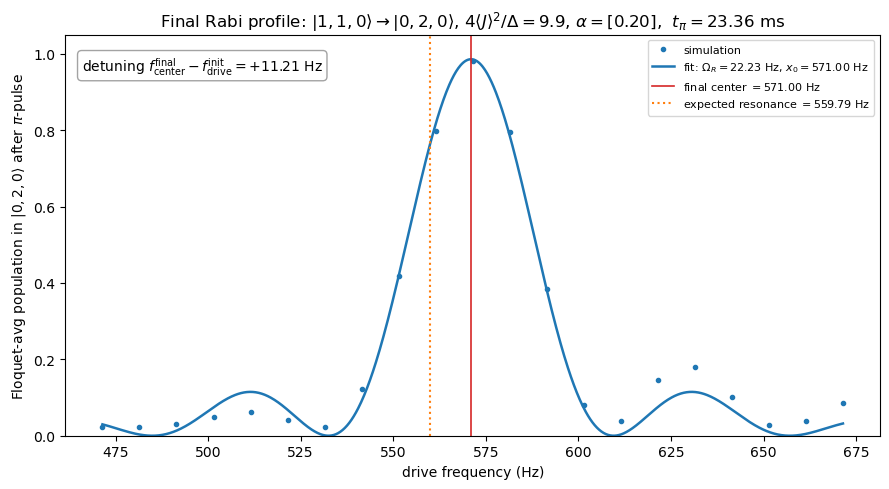

saved figure -> C:\Users\eunic\resonance_Escan.png


In [16]:
# E-U, no walls, 3 sites
res = resonance_Escan(
        state_init   = [1, 1, 0],
        state_target = [0, 2, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = -1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 3, N = 2, dim = 6
init = (0, 1, 1), target = (0, 2, 0)
sideband = +1 -> f_drive_hz_init = 1080.21 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 1080.21 Hz -> T_Rabi = 40.8012 ms (+/- 0.0001), f_Rabi = 24.51 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 1077.093 Hz (+/- 0.216), OmegaR = 25.316 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 1077.09 Hz -> T_Rabi = 41.3696 ms (+/- 0.0001), f_Rabi = 24.17 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 1077.090 Hz (+/- 0.212), OmegaR = 24.857 Hz

=== SUMMARY ===
f_drive_hz_init       = 1080.211 Hz
f_center_rabi_init    = 1077.093 Hz
f_center_rabi_final   = 1077.090 Hz
T_rabi_init           = 40.8012 ms
T_rabi_final      

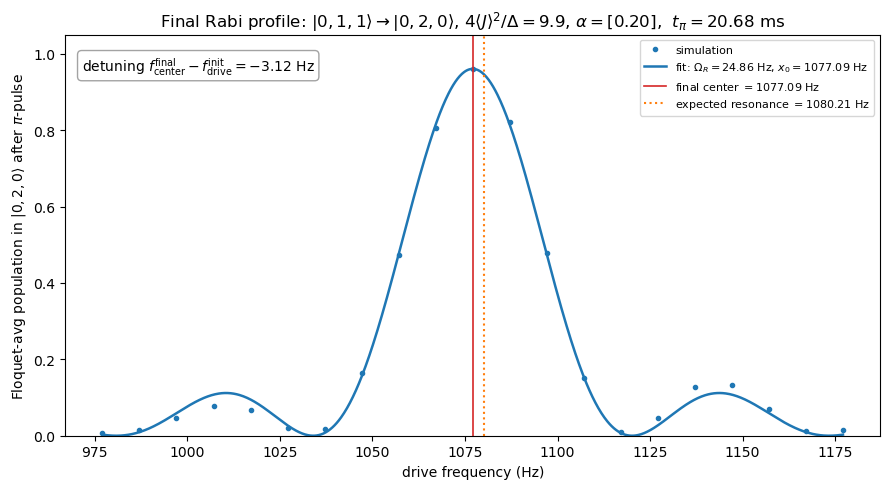

saved figure -> C:\Users\eunic\resonance_Escan.png


In [17]:
# E+U, no walls, 3 sites, lower leg
res = resonance_Escan(
        state_init   = [0, 1, 1],
        state_target = [0, 2, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = +1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 3, N = 2, dim = 6
init = (0, 1, 1), target = (0, 0, 2)
sideband = -1 -> f_drive_hz_init = 559.79 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 559.79 Hz -> T_Rabi = 44.0671 ms (+/- 0.0001), f_Rabi = 22.69 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 569.728 Hz (+/- 0.378), OmegaR = 24.003 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 569.73 Hz -> T_Rabi = 46.5813 ms (+/- 0.0001), f_Rabi = 21.47 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 569.555 Hz (+/- 0.446), OmegaR = 22.313 Hz

=== SUMMARY ===
f_drive_hz_init       = 559.789 Hz
f_center_rabi_init    = 569.728 Hz
f_center_rabi_final   = 569.555 Hz
T_rabi_init           = 44.0671 ms
T_rabi_final          = 46

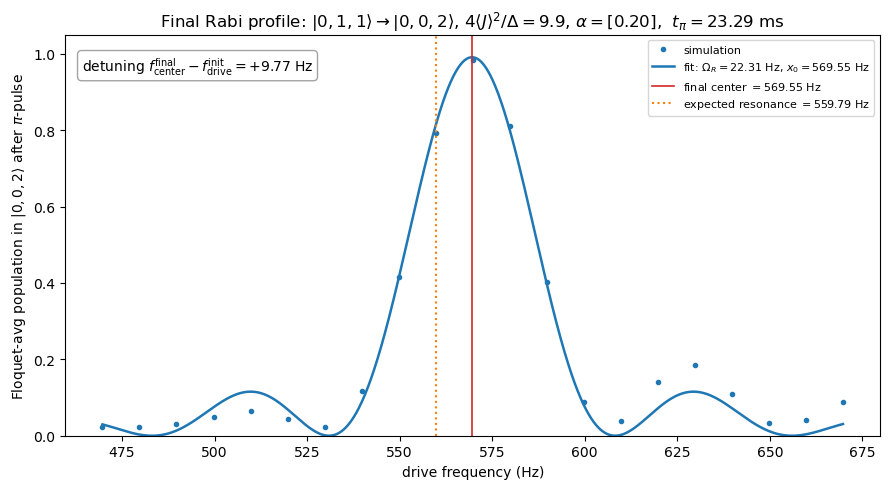

saved figure -> C:\Users\eunic\resonance_Escan.png


In [19]:
# E-U, no walls, 3 sites, lower leg
res = resonance_Escan(
        state_init   = [0, 1, 1],
        state_target = [0, 0, 2],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = -1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 3, N = 2, dim = 6
init = (1, 1, 0), target = (2, 0, 0)
sideband = +1 -> f_drive_hz_init = 1080.21 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 1080.21 Hz -> T_Rabi = 21.9466 ms (+/- 0.0001), f_Rabi = 45.57 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 1123.294 Hz (+/- 0.650), OmegaR = 52.588 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 1123.29 Hz -> T_Rabi = 40.5864 ms (+/- 0.0001), f_Rabi = 24.64 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 1119.785 Hz (+/- 0.204), OmegaR = 25.372 Hz

=== SUMMARY ===
f_drive_hz_init       = 1080.211 Hz
f_center_rabi_init    = 1123.294 Hz
f_center_rabi_final   = 1119.785 Hz
T_rabi_init           = 21.9466 ms
T_rabi_final      

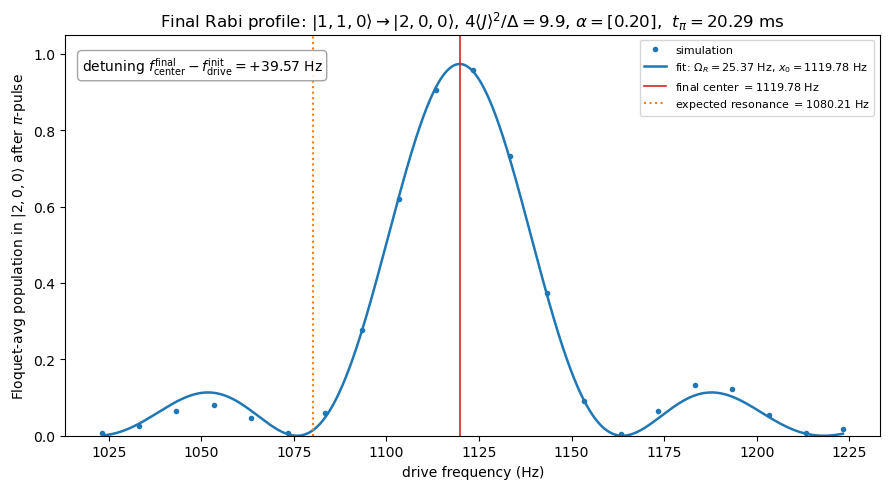

saved figure -> C:\Users\eunic\resonance_Escan.png


In [25]:
# E+U, no walls, 3 sites, upper leg, small chemical potential offset
res = resonance_Escan(
        state_init   = [1, 1, 0],
        state_target = [2, 0, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = +1,
        alpha        = [0.2],
        mu_offset_hz = [40,0,0],
        show         = True
    )

L = 5, N = 2, dim = 15
init = (1, 1, 0, 0, 0), target = (2, 0, 0, 0, 0)
sideband = +1 -> f_drive_hz_init = 1080.21 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 1080.21 Hz -> T_Rabi = 41.1655 ms (+/- 0.0001), f_Rabi = 24.29 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 1079.683 Hz (+/- 0.217), OmegaR = 24.953 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 1079.68 Hz -> T_Rabi = 41.2162 ms (+/- 0.0001), f_Rabi = 24.26 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 1079.678 Hz (+/- 0.216), OmegaR = 24.913 Hz

=== SUMMARY ===
f_drive_hz_init       = 1080.211 Hz
f_center_rabi_init    = 1079.683 Hz
f_center_rabi_final   = 1079.678 Hz
T_rabi_init           = 41.1655 ms
T_rab

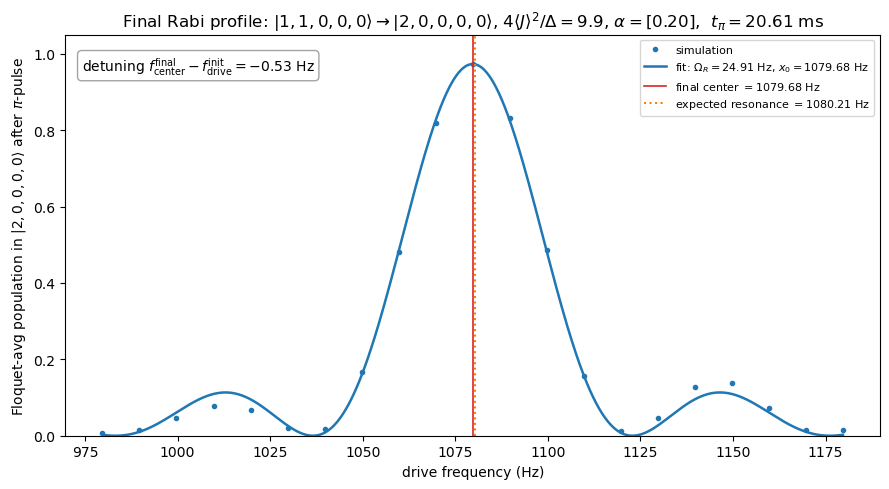

saved figure -> C:\Users\eunic\resonance_Escan.png


In [26]:
# E+U, no walls, 5 sites, leg 0
res = resonance_Escan(
        state_init   = [1, 1, 0, 0, 0],
        state_target = [2, 0, 0, 0, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = +1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 5, N = 2, dim = 15
init = (1, 1, 0, 0, 0), target = (0, 2, 0, 0, 0)
sideband = -1 -> f_drive_hz_init = 559.79 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 559.79 Hz -> T_Rabi = 43.2374 ms (+/- 0.0001), f_Rabi = 23.13 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 571.454 Hz (+/- 0.405), OmegaR = 24.606 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 571.45 Hz -> T_Rabi = 46.7261 ms (+/- 0.0001), f_Rabi = 21.40 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 571.003 Hz (+/- 0.430), OmegaR = 22.229 Hz

=== SUMMARY ===
f_drive_hz_init       = 559.789 Hz
f_center_rabi_init    = 571.454 Hz
f_center_rabi_final   = 571.003 Hz
T_rabi_init           = 43.2374 ms
T_rabi_final 

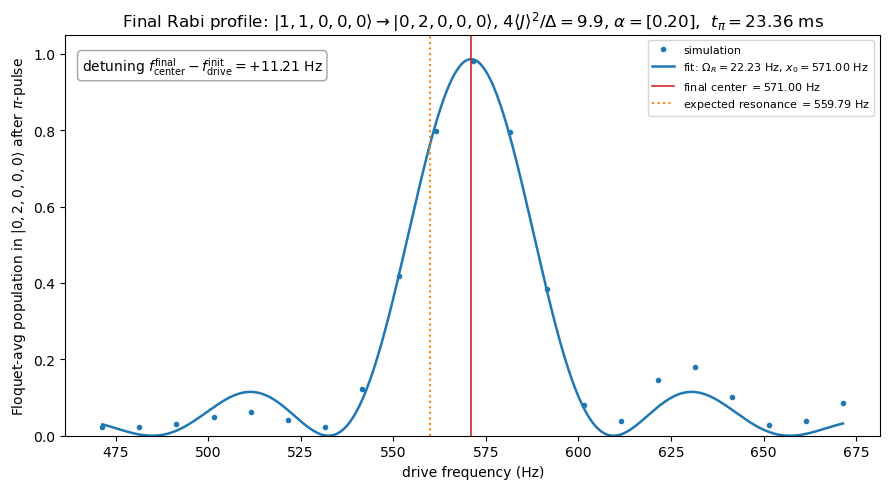

saved figure -> C:\Users\eunic\resonance_Escan.png


In [27]:
# E-U, no walls, 5 sites, leg 0
res = resonance_Escan(
        state_init   = [1, 1, 0, 0, 0],
        state_target = [0, 2, 0, 0, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = -1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 5, N = 2, dim = 15
init = (0, 1, 1, 0, 0), target = (0, 2, 0, 0, 0)
sideband = +1 -> f_drive_hz_init = 1080.21 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 1080.21 Hz -> T_Rabi = 39.9744 ms (+/- 0.0001), f_Rabi = 25.02 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 1074.960 Hz (+/- 0.219), OmegaR = 25.866 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 1074.96 Hz -> T_Rabi = 41.3139 ms (+/- 0.0001), f_Rabi = 24.20 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 1074.882 Hz (+/- 0.216), OmegaR = 24.877 Hz

=== SUMMARY ===
f_drive_hz_init       = 1080.211 Hz
f_center_rabi_init    = 1074.960 Hz
f_center_rabi_final   = 1074.882 Hz
T_rabi_init           = 39.9744 ms
T_rab

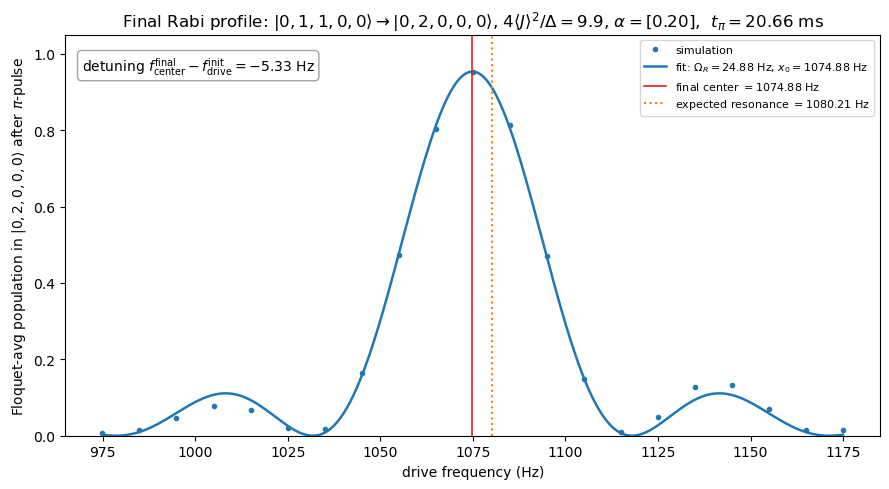

saved figure -> C:\Users\eunic\resonance_Escan.png


In [28]:
# E+U, no walls, 5 sites, leg 1
res = resonance_Escan(
        state_init   = [0, 1, 1, 0, 0],
        state_target = [0, 2, 0, 0, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = +1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 5, N = 2, dim = 15
init = (0, 1, 1, 0, 0), target = (0, 0, 2, 0, 0)
sideband = -1 -> f_drive_hz_init = 559.79 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 559.79 Hz -> T_Rabi = 44.8648 ms (+/- 0.0001), f_Rabi = 22.29 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 568.301 Hz (+/- 0.398), OmegaR = 23.547 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 568.30 Hz -> T_Rabi = 46.5867 ms (+/- 0.0001), f_Rabi = 21.47 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 568.264 Hz (+/- 0.454), OmegaR = 22.301 Hz

=== SUMMARY ===
f_drive_hz_init       = 559.789 Hz
f_center_rabi_init    = 568.301 Hz
f_center_rabi_final   = 568.264 Hz
T_rabi_init           = 44.8648 ms
T_rabi_final 

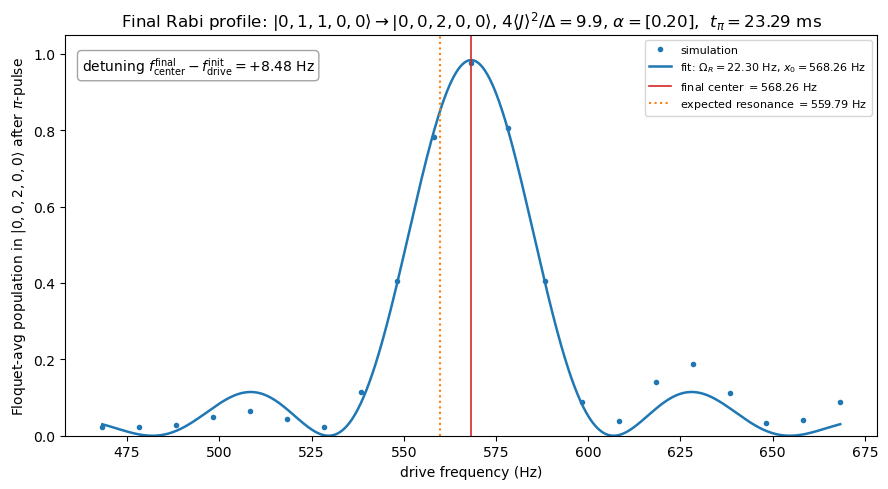

saved figure -> C:\Users\eunic\resonance_Escan.png


In [29]:
# E-U, no walls, 5 sites, leg 1
res = resonance_Escan(
        state_init   = [0, 1, 1, 0, 0],
        state_target = [0, 0, 2, 0, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = -1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 5, N = 2, dim = 15
init = (0, 0, 1, 1, 0), target = (0, 0, 2, 0, 0)
sideband = +1 -> f_drive_hz_init = 1080.21 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 1080.21 Hz -> T_Rabi = 39.9709 ms (+/- 0.0001), f_Rabi = 25.02 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 1074.951 Hz (+/- 0.219), OmegaR = 25.870 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 1074.95 Hz -> T_Rabi = 41.3140 ms (+/- 0.0001), f_Rabi = 24.20 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 1074.874 Hz (+/- 0.215), OmegaR = 24.874 Hz

=== SUMMARY ===
f_drive_hz_init       = 1080.211 Hz
f_center_rabi_init    = 1074.951 Hz
f_center_rabi_final   = 1074.874 Hz
T_rabi_init           = 39.9709 ms
T_rab

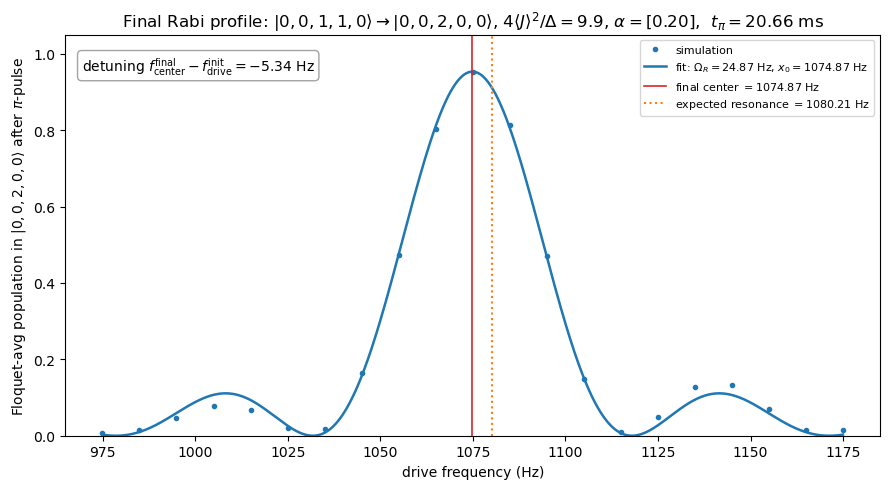

saved figure -> C:\Users\eunic\resonance_Escan.png


In [30]:
# E+U, no walls, 5 sites, leg 2
res = resonance_Escan(
        state_init   = [0, 0, 1, 1, 0],
        state_target = [0, 0, 2, 0, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = +1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 5, N = 2, dim = 15
init = (0, 0, 1, 1, 0), target = (0, 0, 0, 2, 0)
sideband = -1 -> f_drive_hz_init = 559.79 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 559.79 Hz -> T_Rabi = 44.8722 ms (+/- 0.0001), f_Rabi = 22.29 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 568.290 Hz (+/- 0.399), OmegaR = 23.544 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 568.29 Hz -> T_Rabi = 46.5857 ms (+/- 0.0001), f_Rabi = 21.47 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 568.255 Hz (+/- 0.455), OmegaR = 22.302 Hz

=== SUMMARY ===
f_drive_hz_init       = 559.789 Hz
f_center_rabi_init    = 568.290 Hz
f_center_rabi_final   = 568.255 Hz
T_rabi_init           = 44.8722 ms
T_rabi_final 

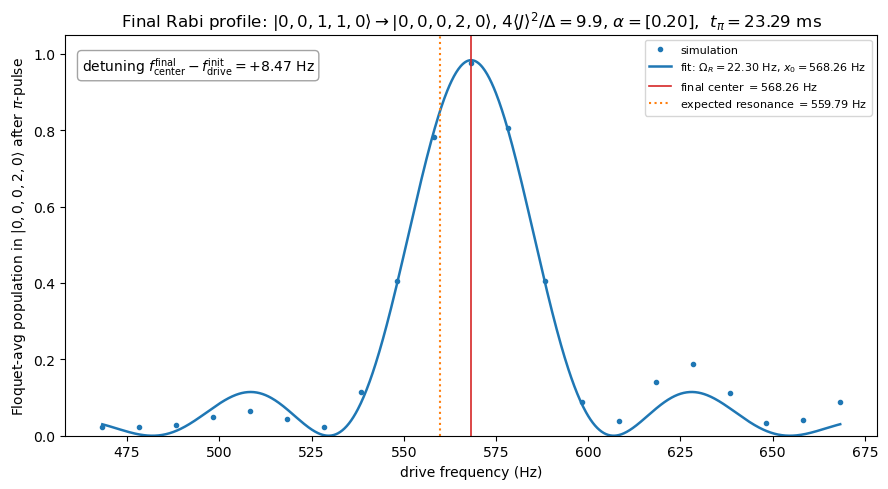

saved figure -> C:\Users\eunic\resonance_Escan.png


In [31]:
# E-U, no walls, 5 sites, leg 2
res = resonance_Escan(
        state_init   = [0, 0, 1, 1, 0],
        state_target = [0, 0, 0, 2, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = -1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 5, N = 2, dim = 15
init = (0, 0, 0, 1, 1), target = (0, 0, 0, 2, 0)
sideband = +1 -> f_drive_hz_init = 1080.21 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 1080.21 Hz -> T_Rabi = 40.7972 ms (+/- 0.0001), f_Rabi = 24.51 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 1077.080 Hz (+/- 0.216), OmegaR = 25.318 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 1077.08 Hz -> T_Rabi = 41.3694 ms (+/- 0.0001), f_Rabi = 24.17 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 1077.076 Hz (+/- 0.211), OmegaR = 24.854 Hz

=== SUMMARY ===
f_drive_hz_init       = 1080.211 Hz
f_center_rabi_init    = 1077.080 Hz
f_center_rabi_final   = 1077.076 Hz
T_rabi_init           = 40.7972 ms
T_rab

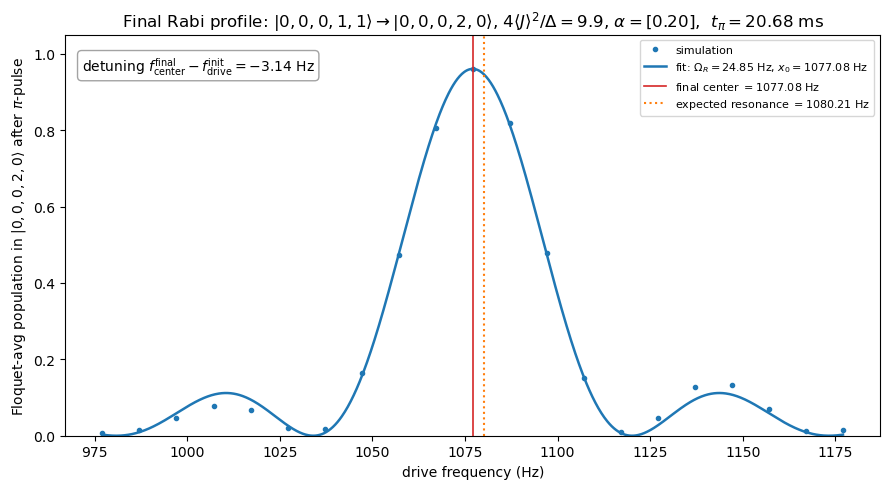

saved figure -> C:\Users\eunic\resonance_Escan.png


In [32]:
# E+U, no walls, 5 sites, leg 3
res = resonance_Escan(
        state_init   = [0, 0, 0, 1, 1],
        state_target = [0, 0, 0, 2, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = +1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 5, N = 2, dim = 15
init = (0, 0, 0, 1, 1), target = (0, 0, 0, 0, 2)
sideband = -1 -> f_drive_hz_init = 559.79 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 559.79 Hz -> T_Rabi = 44.0711 ms (+/- 0.0001), f_Rabi = 22.69 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 569.719 Hz (+/- 0.378), OmegaR = 24.000 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 569.72 Hz -> T_Rabi = 46.5816 ms (+/- 0.0001), f_Rabi = 21.47 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 569.547 Hz (+/- 0.446), OmegaR = 22.312 Hz

=== SUMMARY ===
f_drive_hz_init       = 559.789 Hz
f_center_rabi_init    = 569.719 Hz
f_center_rabi_final   = 569.547 Hz
T_rabi_init           = 44.0711 ms
T_rabi_final 

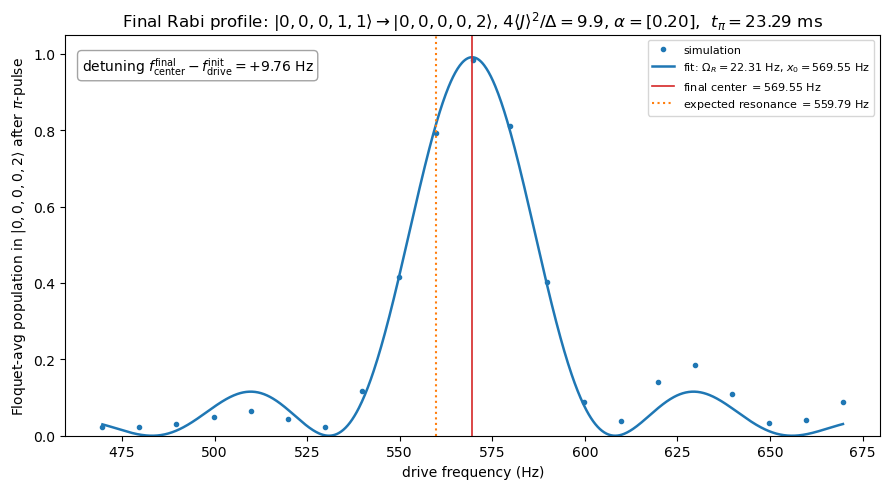

saved figure -> C:\Users\eunic\resonance_Escan.png


In [34]:
# E-U, no walls, 5 sites, leg 3
res = resonance_Escan(
        state_init   = [0, 0, 0, 1, 1],
        state_target = [0, 0, 0, 0, 2],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = -1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 7, N = 2, dim = 28
init = (1, 1, 0, 0, 0, 0, 0), target = (2, 0, 0, 0, 0, 0, 0)
sideband = +1 -> f_drive_hz_init = 1080.21 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 1080.21 Hz -> T_Rabi = 41.1655 ms (+/- 0.0001), f_Rabi = 24.29 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 1079.683 Hz (+/- 0.217), OmegaR = 24.953 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 1079.68 Hz -> T_Rabi = 41.2162 ms (+/- 0.0001), f_Rabi = 24.26 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 1079.678 Hz (+/- 0.216), OmegaR = 24.913 Hz

=== SUMMARY ===
f_drive_hz_init       = 1080.211 Hz
f_center_rabi_init    = 1079.683 Hz
f_center_rabi_final   = 1079.678 Hz
T_rabi_init           = 41.1

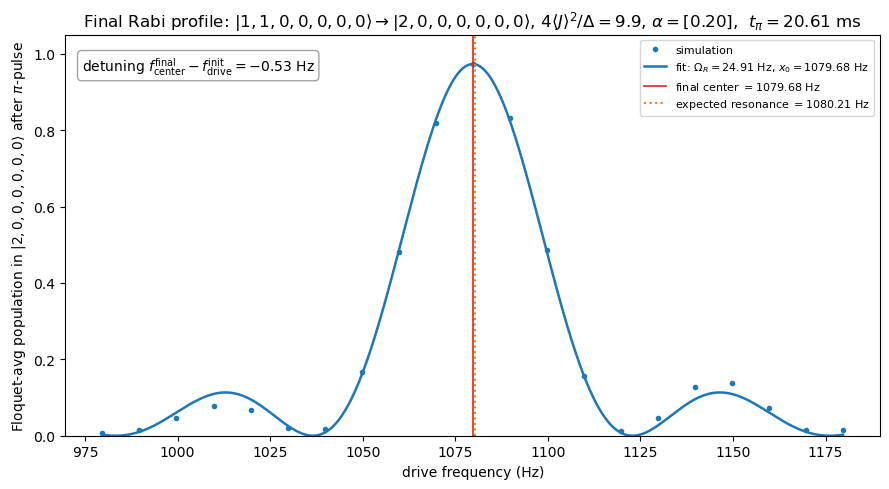

saved figure -> C:\Users\eunic\resonance_Escan.png


In [33]:
# E+U, no walls, 7 sites, leg 0
res = resonance_Escan(
        state_init   = [1, 1, 0, 0, 0, 0, 0],
        state_target = [2, 0, 0, 0, 0, 0, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = +1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 7, N = 2, dim = 28
init = (1, 1, 0, 0, 0, 0, 0), target = (0, 2, 0, 0, 0, 0, 0)
sideband = -1 -> f_drive_hz_init = 559.79 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 559.79 Hz -> T_Rabi = 43.2374 ms (+/- 0.0001), f_Rabi = 23.13 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 571.454 Hz (+/- 0.405), OmegaR = 24.606 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 571.45 Hz -> T_Rabi = 46.7261 ms (+/- 0.0001), f_Rabi = 21.40 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 571.003 Hz (+/- 0.430), OmegaR = 22.229 Hz

=== SUMMARY ===
f_drive_hz_init       = 559.789 Hz
f_center_rabi_init    = 571.454 Hz
f_center_rabi_final   = 571.003 Hz
T_rabi_init           = 43.2374 ms
T

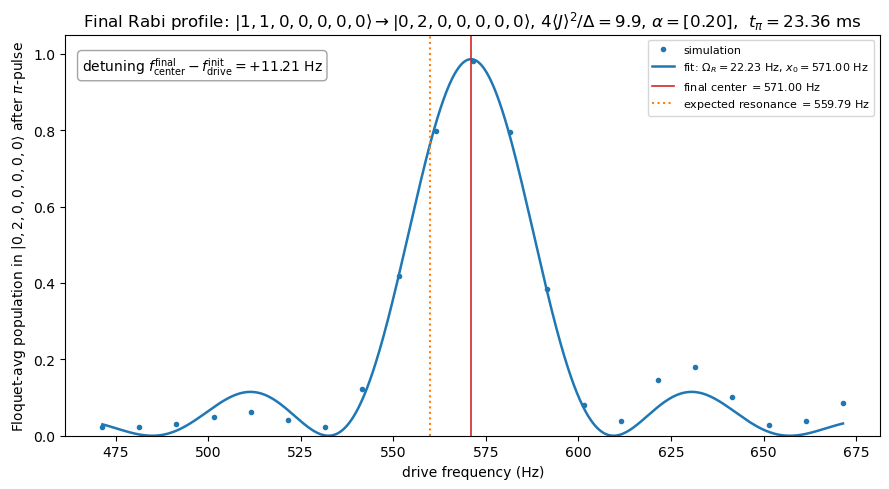

saved figure -> C:\Users\eunic\resonance_Escan.png


In [35]:
# E-U, no walls, 7 sites, leg 0
res = resonance_Escan(
        state_init   = [1, 1, 0, 0, 0, 0, 0],
        state_target = [0, 2, 0, 0, 0, 0, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = -1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 7, N = 2, dim = 28
init = (0, 0, 1, 1, 0, 0, 0), target = (0, 0, 2, 0, 0, 0, 0)
sideband = +1 -> f_drive_hz_init = 1080.21 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 1080.21 Hz -> T_Rabi = 39.9686 ms (+/- 0.0001), f_Rabi = 25.02 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 1074.947 Hz (+/- 0.219), OmegaR = 25.872 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 1074.95 Hz -> T_Rabi = 41.3137 ms (+/- 0.0001), f_Rabi = 24.21 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 1074.869 Hz (+/- 0.215), OmegaR = 24.874 Hz

=== SUMMARY ===
f_drive_hz_init       = 1080.211 Hz
f_center_rabi_init    = 1074.947 Hz
f_center_rabi_final   = 1074.869 Hz
T_rabi_init           = 39.9

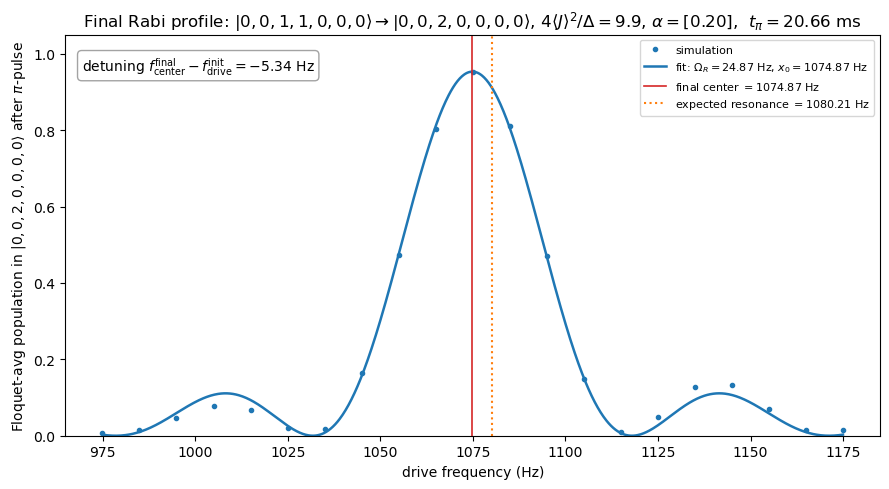

saved figure -> C:\Users\eunic\resonance_Escan.png


In [36]:
# E+U, no walls, 7 sites, leg 2
res = resonance_Escan(
        state_init   = [0, 0, 1, 1, 0, 0, 0],
        state_target = [0, 0, 2, 0, 0, 0, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = +1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 7, N = 2, dim = 28
init = (0, 0, 1, 1, 0, 0, 0), target = (0, 0, 0, 2, 0, 0, 0)
sideband = -1 -> f_drive_hz_init = 559.79 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 559.79 Hz -> T_Rabi = 44.8688 ms (+/- 0.0001), f_Rabi = 22.29 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 568.292 Hz (+/- 0.398), OmegaR = 23.544 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 568.29 Hz -> T_Rabi = 46.5869 ms (+/- 0.0001), f_Rabi = 21.47 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 568.256 Hz (+/- 0.454), OmegaR = 22.300 Hz

=== SUMMARY ===
f_drive_hz_init       = 559.789 Hz
f_center_rabi_init    = 568.292 Hz
f_center_rabi_final   = 568.256 Hz
T_rabi_init           = 44.8688 ms
T

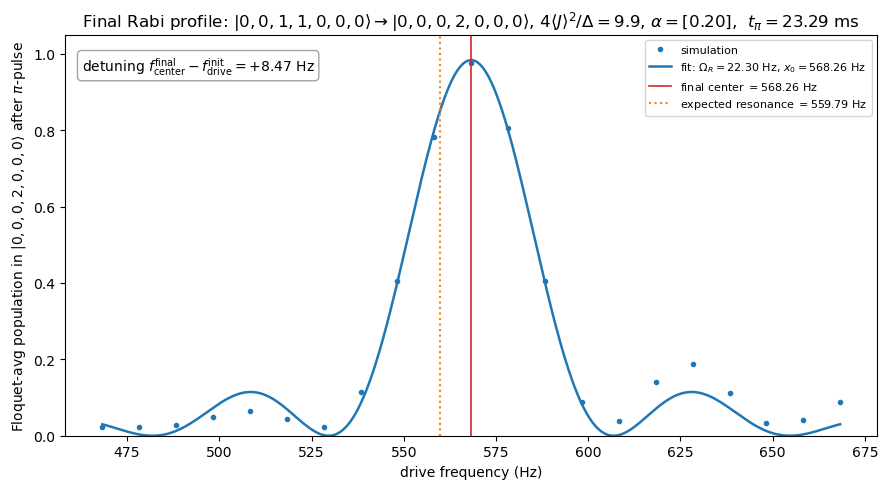

saved figure -> C:\Users\eunic\resonance_Escan.png


In [37]:
# E-U, no walls, 7 sites, leg 2
res = resonance_Escan(
        state_init   = [0, 0, 1, 1, 0, 0, 0],
        state_target = [0, 0, 0, 2, 0, 0, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = -1,
        alpha        = [0.2],
        mu_offset_hz = [],
        show         = True
    )

L = 5, N = 2, dim = 15
init = (0, 1, 1, 0, 0), target = (0, 2, 0, 0, 0)
sideband = +1 -> f_drive_hz_init = 1080.21 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 1080.21 Hz -> T_Rabi = 40.9847 ms (+/- 0.0001), f_Rabi = 24.40 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 1078.775 Hz (+/- 0.220), OmegaR = 25.097 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 1078.78 Hz -> T_Rabi = 41.1676 ms (+/- 0.0001), f_Rabi = 24.29 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 1078.768 Hz (+/- 0.218), OmegaR = 24.948 Hz

=== SUMMARY ===
f_drive_hz_init       = 1080.211 Hz
f_center_rabi_init    = 1078.775 Hz
f_center_rabi_final   = 1078.768 Hz
T_rabi_init           = 40.9847 ms
T_rab

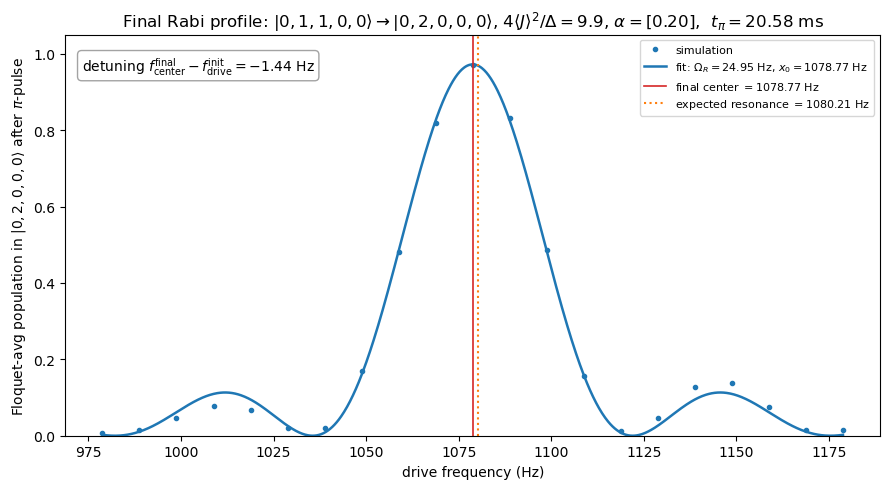

saved figure -> C:\Users\eunic\resonance_Escan.png


In [40]:
# E+U, with walls, 5 sites, leg 1
res = resonance_Escan(
        state_init   = [0, 1, 1, 0, 0],
        state_target = [0, 2, 0, 0, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = +1,
        alpha        = [0.2],
        mu_offset_hz = [2000,0,0,0,2000],
        show         = True
    )

L = 5, N = 2, dim = 15
init = (0, 1, 1, 0, 0), target = (0, 0, 2, 0, 0)
sideband = -1 -> f_drive_hz_init = 559.79 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 559.79 Hz -> T_Rabi = 43.6736 ms (+/- 0.0001), f_Rabi = 22.90 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 570.631 Hz (+/- 0.387), OmegaR = 24.285 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 570.63 Hz -> T_Rabi = 46.6626 ms (+/- 0.0001), f_Rabi = 21.43 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 570.324 Hz (+/- 0.435), OmegaR = 22.276 Hz

=== SUMMARY ===
f_drive_hz_init       = 559.789 Hz
f_center_rabi_init    = 570.631 Hz
f_center_rabi_final   = 570.324 Hz
T_rabi_init           = 43.6736 ms
T_rabi_final 

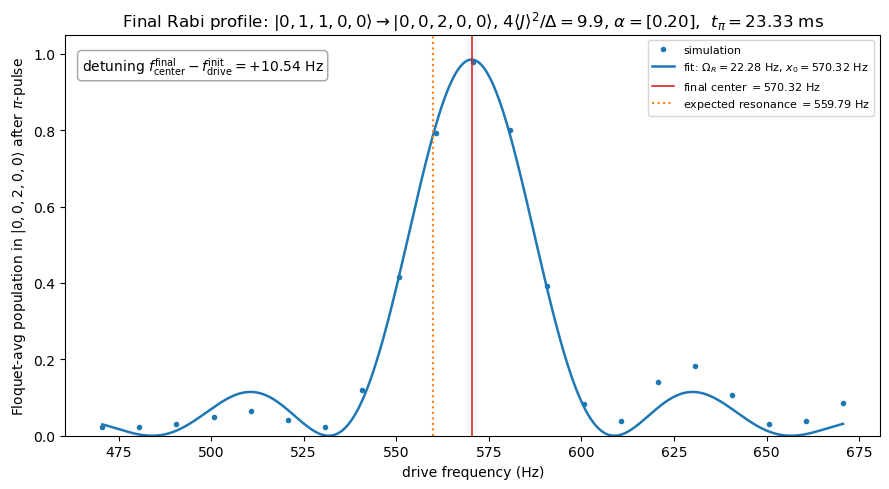

saved figure -> C:\Users\eunic\resonance_Escan.png


In [41]:
# E-U, with walls, 5 sites, leg 1
res = resonance_Escan(
        state_init   = [0, 1, 1, 0, 0],
        state_target = [0, 0, 2, 0, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = -1,
        alpha        = [0.2],
        mu_offset_hz = [2000,0,0,0,2000],
        show         = True
    )

L = 5, N = 2, dim = 15
init = (0, 0, 1, 1, 0), target = (0, 0, 2, 0, 0)
sideband = +1 -> f_drive_hz_init = 1080.21 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 1080.21 Hz -> T_Rabi = 42.2689 ms (+/- 0.0001), f_Rabi = 23.66 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 1079.377 Hz (+/- 0.186), OmegaR = 24.506 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 1079.38 Hz -> T_Rabi = 42.3529 ms (+/- 0.0001), f_Rabi = 23.61 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 1079.376 Hz (+/- 0.187), OmegaR = 24.455 Hz

=== SUMMARY ===
f_drive_hz_init       = 1080.211 Hz
f_center_rabi_init    = 1079.377 Hz
f_center_rabi_final   = 1079.376 Hz
T_rabi_init           = 42.2689 ms
T_rab

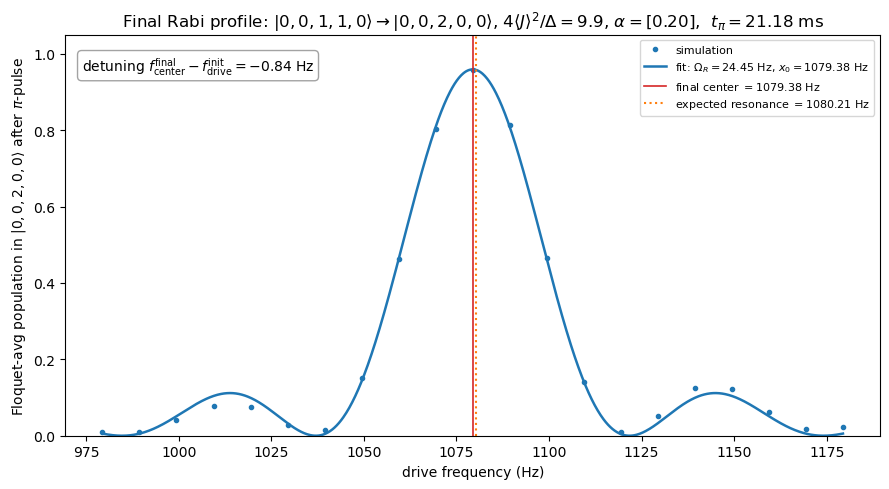

saved figure -> C:\Users\eunic\resonance_Escan.png


In [42]:
# E+U, with walls, 5 sites, leg 2
res = resonance_Escan(
        state_init   = [0, 0, 1, 1, 0],
        state_target = [0, 0, 2, 0, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = +1,
        alpha        = [0.2],
        mu_offset_hz = [2000,0,0,0,2000],
        show         = True
    )

L = 5, N = 2, dim = 15
init = (0, 0, 1, 1, 0), target = (0, 0, 0, 2, 0)
sideband = -1 -> f_drive_hz_init = 559.79 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 559.79 Hz -> T_Rabi = 42.6290 ms (+/- 0.0001), f_Rabi = 23.46 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 572.929 Hz (+/- 0.425), OmegaR = 25.176 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 572.93 Hz -> T_Rabi = 47.3213 ms (+/- 0.0001), f_Rabi = 21.13 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 572.178 Hz (+/- 0.394), OmegaR = 21.953 Hz

=== SUMMARY ===
f_drive_hz_init       = 559.789 Hz
f_center_rabi_init    = 572.929 Hz
f_center_rabi_final   = 572.178 Hz
T_rabi_init           = 42.6290 ms
T_rabi_final 

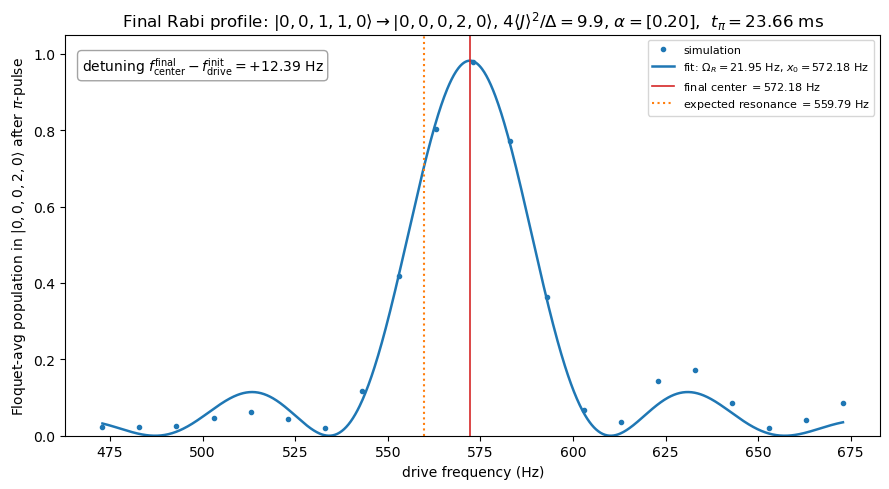

saved figure -> C:\Users\eunic\resonance_Escan.png


In [44]:
# E-U, with walls, 5 sites, leg 2
res = resonance_Escan(
        state_init   = [0, 0, 1, 1, 0],
        state_target = [0, 0, 0, 2, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = -1,
        alpha        = [0.2],
        mu_offset_hz = [2000,0,0,0,2000],
        show         = True
    )

L = 5, N = 2, dim = 15
init = (0, 1, 1, 0, 0), target = (0, 2, 0, 0, 0)
sideband = +1 -> f_drive_hz_init = 1080.21 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 1080.21 Hz -> T_Rabi = 41.1971 ms (+/- 0.0001), f_Rabi = 24.27 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 1078.763 Hz (+/- 0.187), OmegaR = 24.753 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 1078.76 Hz -> T_Rabi = 41.4049 ms (+/- 0.0001), f_Rabi = 24.15 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 1078.740 Hz (+/- 0.183), OmegaR = 24.587 Hz

=== SUMMARY ===
f_drive_hz_init       = 1080.211 Hz
f_center_rabi_init    = 1078.763 Hz
f_center_rabi_final   = 1078.740 Hz
T_rabi_init           = 41.1971 ms
T_rab

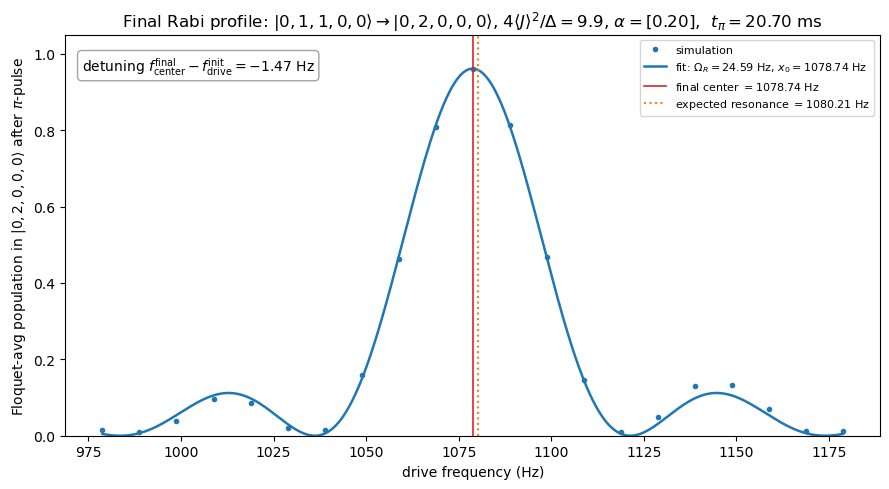

saved figure -> C:\Users\eunic\resonance_Escan.png


In [46]:
# E-U, with walls, 5 sites, leg 2
res = resonance_Escan(
        state_init   = [0, 1, 1, 0, 0],
        state_target = [0, 2, 0, 0, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = +1,
        alpha        = [0.2],
        mu_offset_hz = [400.0,0,0,0,400.0],
        show         = True
    )

L = 5, N = 2, dim = 15
init = (0, 1, 1, 0, 0), target = (0, 0, 2, 0, 0)
sideband = -1 -> f_drive_hz_init = 559.79 Hz
static depth V0 = 7.5 Er -> J(V0) = 43.3228 Hz
U_mean_0 = 260.2113 Hz, U(V0) = 260.8204 Hz
J_mean_0      = 44.9782 Hz
J(V0)         = 43.3228 Hz

=== STEP 2: preliminary time scan at f_drive_hz_init ===
[time init] f_drive = 559.79 Hz -> T_Rabi = 44.3048 ms (+/- 0.0001), f_Rabi = 22.57 Hz

=== STEP 3: frequency profile scan (pi-pulse from T_rabi_init) ===
[profile init] center x0 = 569.353 Hz (+/- 0.379), OmegaR = 23.861 Hz

=== STEP 4: resonant time scan at f_center_rabi_init ===
[time final] f_drive = 569.35 Hz -> T_Rabi = 46.6066 ms (+/- 0.0001), f_Rabi = 21.46 Hz

=== STEP 5: profile scan with resonant pi-pulse (T_rabi_final) ===
[profile final] center x0 = 569.245 Hz (+/- 0.444), OmegaR = 22.294 Hz

=== SUMMARY ===
f_drive_hz_init       = 559.789 Hz
f_center_rabi_init    = 569.353 Hz
f_center_rabi_final   = 569.245 Hz
T_rabi_init           = 44.3048 ms
T_rabi_final 

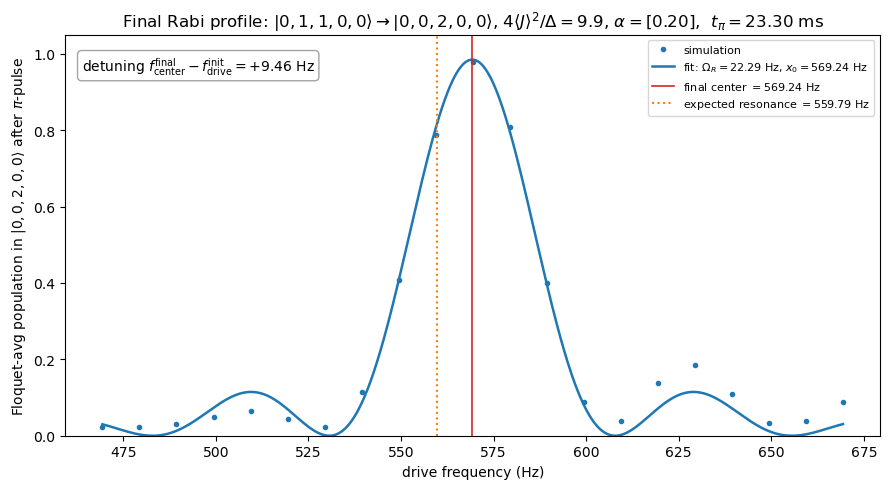

saved figure -> C:\Users\eunic\resonance_Escan.png


In [47]:
# E-U, with walls, 5 sites, leg 2
res = resonance_Escan(
        state_init   = [0, 1, 1, 0, 0],
        state_target = [0, 0, 2, 0, 0],
        V0_ER        = 7.5,
        Delta_hz     = 820.0,
        sideband     = -1,
        alpha        = [0.2],
        mu_offset_hz = [400.0,0,0,0,400.0],
        show         = True
    )